In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.11.0+cpu


In [3]:
#transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#load training data
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training samples: {len(trainset)}")
print(f"Testing samples: {len(testset)}")

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Testing samples: 10000


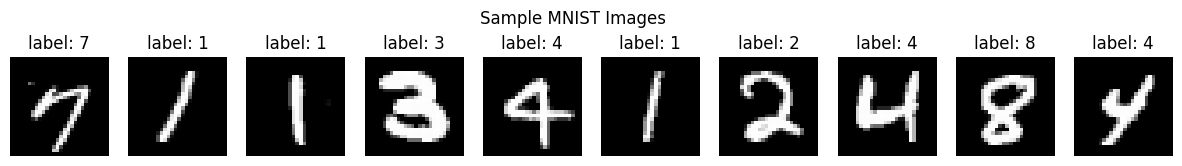

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [7]:
#get one batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

#plot the first 10 images and labels
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f"label: {labels[i].item()}")
    axes[i].axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

In [ ]:
#define the neural network architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #28x28x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) #14x14x64

        #pooling layer to reduce spatial dimensions
        self.pool = nn.MaxPool2d(2, 2)
        #fully connected layer to output 10 classes
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7) #flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
#create the model and move it to the device
model = CNN().to(device)
print(model)